In [1]:
from dinosaw.models.lightning_model import PEModel
from dinosaw.utils import normalize, load_image, resize_crop, do_2D_pca
import torch
import matplotlib.pyplot as plt

/home/ab_aimd_anja_20884/anaconda3/envs/moritz_eng_new/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
model = PEModel.load_from_checkpoint("/home/ab_aimd_anja_20884/Pawlowsky_Moritz/England/DINOMO/dinosaw/trained_models/test-epoch=19-val_loss=0.02.ckpt")

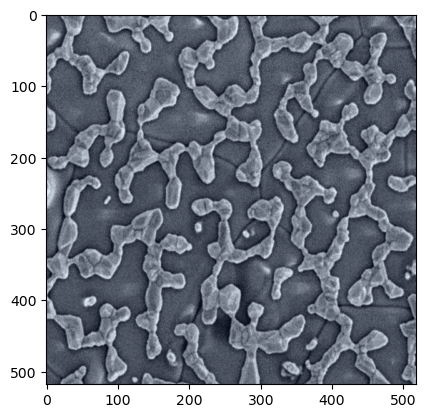

In [3]:
img_size = 1*518
test_img = load_image("images/default_image.jpg", resize_crop((img_size, img_size), (img_size, img_size)))[0]
plt.imshow(normalize(test_img.cpu().squeeze().permute(1,2,0).float()))

In [4]:
res = model(test_img.float())
res.shape

torch.Size([1, 384, 37, 37])

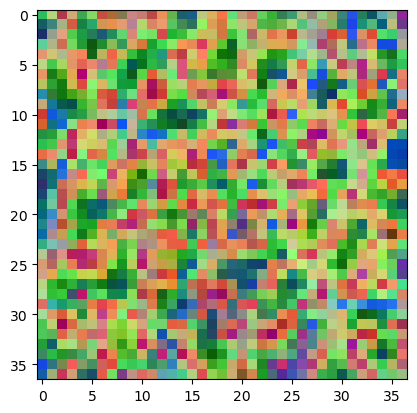

In [5]:
plt.imshow(do_2D_pca(res.cpu().squeeze(), n_components=3, post_norm="minmax"))

In [6]:
from dinosaw.utils import probe
from dinosaw.datasets.translate_featurise import translate_featurise

In [7]:
cleaned_test_img = translate_featurise(test_img.cpu().float(), model.vit, max_batch_size=2)

(384, 37, 37)
(384, 37, 37)
(384, 37, 37)
(384, 37, 37)
(384, 37, 37)
(384, 37, 37)
(384, 37, 37)
(384, 37, 37)


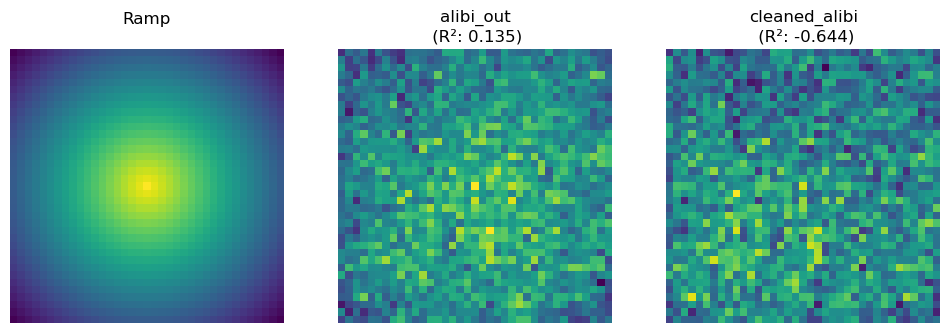

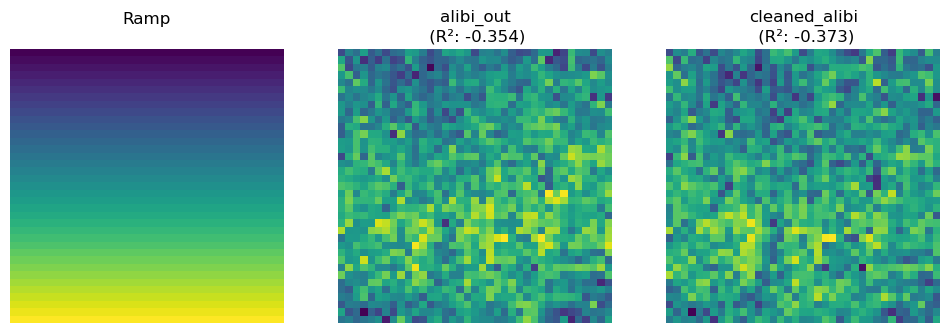

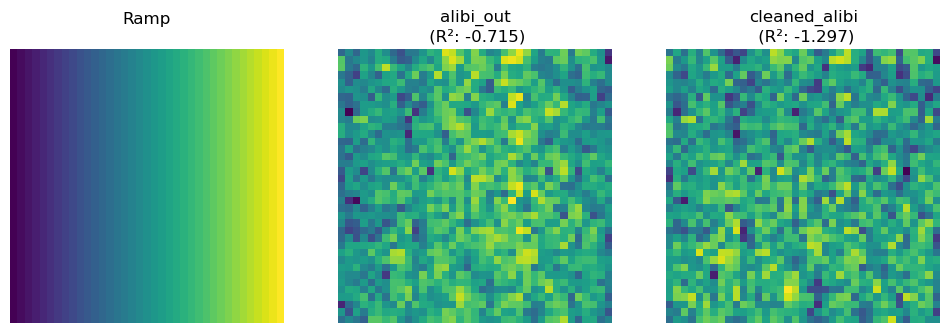

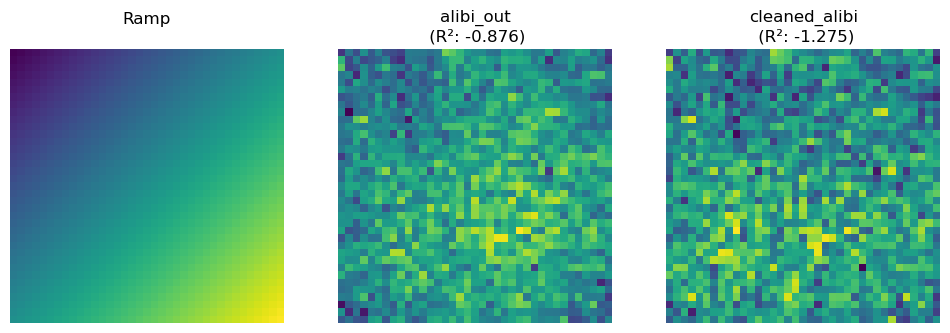

In [10]:
probe([res, cleaned_test_img], [False, False], ["alibi_out", "cleaned_alibi"], ramp="radial")
probe([res, cleaned_test_img], [False, False], ["alibi_out", "cleaned_alibi"], ramp="ud")
probe([res, cleaned_test_img], [False, False], ["alibi_out", "cleaned_alibi"], ramp="lr")
probe([res, cleaned_test_img], [False, False], ["alibi_out", "cleaned_alibi"], ramp="diag")